In [ ]:
from google.colab import files
uploaded = files.upload()

KeyboardInterrupt: 

#Task 1 – Logistic Regression for Binary Classification

Dataset shape: (667, 20)

Columns: ['State', 'Account length', 'Area code', 'International plan', 'Voice mail plan', 'Number vmail messages', 'Total day minutes', 'Total day calls', 'Total day charge', 'Total eve minutes', 'Total eve calls', 'Total eve charge', 'Total night minutes', 'Total night calls', 'Total night charge', 'Total intl minutes', 'Total intl calls', 'Total intl charge', 'Customer service calls', 'Churn']

Churn distribution:
 Churn
False    572
True      95
Name: count, dtype: int64

Accuracy: 0.8582089552238806

Classification Report:

              precision    recall  f1-score   support

    No Churn       0.88      0.97      0.92       115
       Churn       0.50      0.16      0.24        19

    accuracy                           0.86       134
   macro avg       0.69      0.57      0.58       134
weighted avg       0.82      0.86      0.83       134



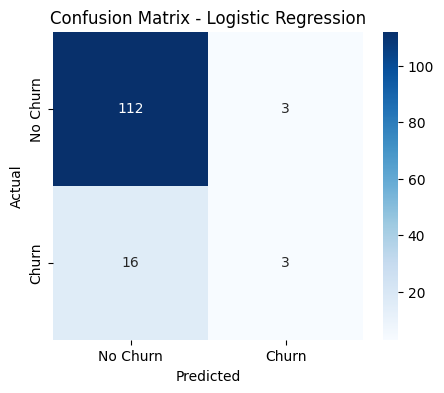

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Load churn dataset
df_churn = pd.read_csv('churn-bigml-20.csv')

# Basic info
print("Dataset shape:", df_churn.shape)
print("\nColumns:", df_churn.columns.tolist())

# Target column: Churn (True/False)
print("\nChurn distribution:\n", df_churn['Churn'].value_counts())

# Encode categorical columns
categorical_cols = ['State', 'International plan', 'Voice mail plan']
le = LabelEncoder()
for col in categorical_cols:
    df_churn[col] = le.fit_transform(df_churn[col])

# Features and target
X = df_churn.drop('Churn', axis=1)
y = df_churn['Churn'].astype(int)

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

# Train Logistic Regression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Results
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

#Task 3 – K-Means Clustering

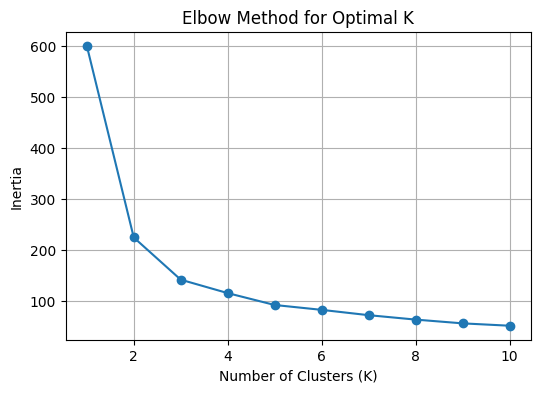


Cluster distribution:
 Cluster
0    53
1    50
2    47
Name: count, dtype: int64

First 10 rows with cluster labels:

   sepal_length  sepal_width  petal_length  petal_width species  Cluster
0           5.1          3.5           1.4          0.2  setosa        1
1           4.9          3.0           1.4          0.2  setosa        1
2           4.7          3.2           1.3          0.2  setosa        1
3           4.6          3.1           1.5          0.2  setosa        1
4           5.0          3.6           1.4          0.2  setosa        1
5           5.4          3.9           1.7          0.4  setosa        1
6           4.6          3.4           1.4          0.3  setosa        1
7           5.0          3.4           1.5          0.2  setosa        1
8           4.4          2.9           1.4          0.2  setosa        1
9           4.9          3.1           1.5          0.1  setosa        1


In [5]:
# Load iris dataset for clustering
df_iris = pd.read_csv('iris.csv')

# Drop target column (species) for unsupervised learning
X_iris = df_iris.drop('species', axis=1)

# Scale features
scaler = StandardScaler()
X_scaled_iris = scaler.fit_transform(X_iris)

# Elbow method to find optimal number of clusters
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
k_range = range(1, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled_iris)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(k_range, inertia, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()

# Train K-Means with K=3 (optimal for iris)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(X_scaled_iris)
labels = kmeans.labels_

# Add cluster labels to original data
df_iris['Cluster'] = labels
print("\nCluster distribution:\n", df_iris['Cluster'].value_counts())

# Show first 10 rows with cluster
print("\nFirst 10 rows with cluster labels:\n")
print(df_iris.head(10))